In [1]:
import sys
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm

In [2]:
sys.path.append("/home/alexis/Documents/COMP558/COMP558-FinalProject/code/")
# sys.path.append("/workspaces/python-opencv/repo/code/")

In [3]:
from tracker import Tracker
from optical_flow.bounding_box import BoundingBox
from feature_detection.shi_tomasi import ShiTomasiDetector
from feature_description.orb_descriptor import ORBDescriptor
from optical_flow.lucas_kanade import LucasKanade
from segmentation.fuzzy_c_means import FuzzyCMeansSegmenter
from optical_flow.bounding_box import expand_bounding_box

In [4]:
video_name = "/home/alexis/Documents/master/vision/repo/libfreenect/wrappers/python/out/VIDEO-20250113-190349.mp4"
depth_name = "/home/alexis/Documents/master/vision/repo/libfreenect/wrappers/python/out/DEPTH-20250113-190349.mp4"

output_name = "out/complete.mp4"

In [5]:
x, y, w, h = 275, 200, 110, 85

shi_tomasi_params = dict(params = dict( maxCorners = 1000, qualityLevel = 0.01, minDistance = 5, blockSize = 5))
orb_params = {"params": {"nfeatures" : 10000, "edgeThreshold" : 5, "patchSize" : 5}}
gu_params = {"_lambda" : 4/5, "frame_buffer" : 60, "gamma" : 0.1, "gamma_fit" : 0.5, "gamma_drift" : 0.5}
lucas_kanade_params = {}
c_means_params = {"n_groups" : 5, "target_error" : 0, "neighbourhood_size" : 10, "m" : 2, "lambda_val" : 2, "max_iter" : 10}

In [6]:
initial_bbox = BoundingBox(x, y, w, h)
initial_bbox = expand_bounding_box(initial_bbox, 2)

feature_detector = ShiTomasiDetector(**shi_tomasi_params)
feature_descriptor = ORBDescriptor(**orb_params)
optical_flow = LucasKanade(**lucas_kanade_params)
segmenter = FuzzyCMeansSegmenter(**c_means_params)

In [7]:
cap_video = cv.VideoCapture(video_name)
cap_depth = cv.VideoCapture(depth_name)

ret_video, frame_video = cap_video.read()
ret_depth, frame_depth = cap_depth.read()

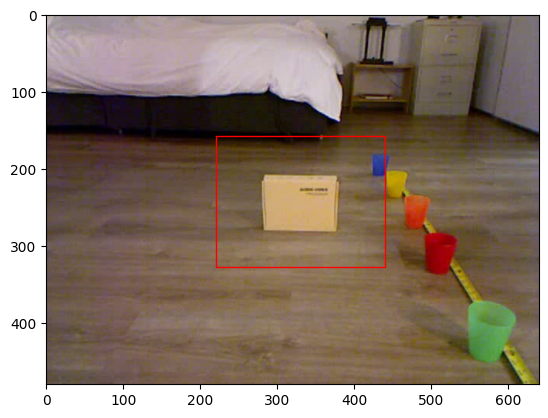

In [8]:
fig, ax = plt.subplots()

ax.imshow(frame_video[:,:,::-1])

rect = patches.Rectangle((initial_bbox.x, initial_bbox.y), initial_bbox.w, initial_bbox.h, linewidth=1, edgecolor='r', facecolor='none')
ax.add_patch(rect)

plt.show()

In [9]:
tracker = Tracker(frame_video, initial_bbox, feature_detector, optical_flow, feature_descriptor, segmenter, gu_params)

DroTrackBBOXStats(scale=0.3541666666666667, delta=(-28, 23))


In [10]:
fps = cap_video.get(cv.CAP_PROP_FPS)

fourcc = cv.VideoWriter_fourcc(*'mp4v')
video_writer = cv.VideoWriter(output_name, fourcc, fps, frame_video.shape[:-1][::-1])

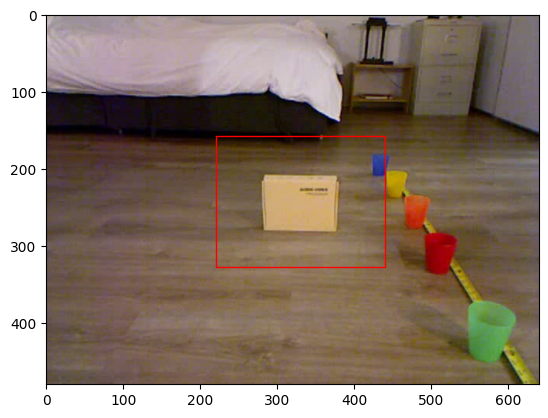

In [11]:
fig, ax = plt.subplots()

ax.imshow(frame_video[:,:,::-1])

rect = patches.Rectangle((initial_bbox.x, initial_bbox.y), initial_bbox.w, initial_bbox.h, linewidth=1, edgecolor='r', facecolor='none')
ax.add_patch(rect)

plt.show()

In [12]:
print(tracker.bbox_stats)
print(tracker.points)

DroTrackBBOXStats(scale=0.3541666666666667, delta=(-28, 23))
[[364. 227.]
 [330. 227.]
 [285. 209.]
 [378. 217.]
 [284. 279.]
 [375. 211.]
 [347. 227.]
 [281. 217.]
 [357. 159.]
 [375. 280.]
 [358. 228.]
 [438. 208.]
 [425. 208.]
 [338. 228.]
 [279. 278.]
 [280. 259.]
 [380. 258.]]


BoundingBox(x=np.float32(279.0), y=np.float32(159.0), w=np.float32(159.0), h=np.float32(121.0))
BoundingBox(x=220, y=157, w=220, h=170)


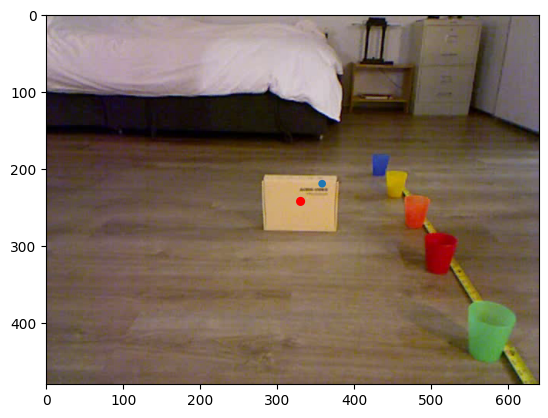

In [13]:
fig, ax = plt.subplots()

ax.imshow(frame_video[:,:,::-1])
from optical_flow.bounding_box import points_to_bbox
from optical_flow.bounding_box import points_clean_up

# coord = np.mean(tracker.points, axis = 0)
coord = points_to_bbox(points_clean_up(tracker.points))

circ = patches.Circle((coord.cx, coord.cy))
print(coord)
ax.add_patch(circ)

circ2 = patches.Circle((initial_bbox.cx, initial_bbox.cy), color="r")
print(initial_bbox)
ax.add_patch(circ2)

plt.show()

In [14]:
length = int(cap_video.get(cv.CAP_PROP_FRAME_COUNT))

for i in tqdm(range(length)):

    if not (ret_video and ret_depth):
        break

    bbox = tracker.track(frame_video)

    img2 = cv.rectangle(frame_video, (bbox.x, bbox.y), (bbox.x + bbox.w, bbox.y + bbox.h), 255, 2)

    video_writer.write(img2)

    ret_video, frame_video = cap_video.read()
    ret_depth, frame_depth = cap_depth.read()

  0%|          | 0/479 [00:00<?, ?it/s]


NameError: name 'img2' is not defined

In [15]:
video_writer.release()

In [16]:
tracker.recovery_moment

[]